# Banking EDA ve Baseline Modelleme

Bu not defteri `birlestirilmis_bankacilik_verileri.csv` dosyası üzerinde basit bir keşifsel veri analizi (EDA) ve baseline sınıflandırma modelleri çalıştırmak için hazırlanmıştır. Amaç: veri yapısını anlamak, temel temizleme, kısa bir özellik mühendisliği, sınıflandırma modelleriyle hızlı değerlendirme ve sonuçların kaydedilmesidir.


In [ ]:
# Gerekli paketleri (varsa) yükleyin
# Eğer ortamınızda paketler yüklü değilse şu hücreyi çalıştırın:
!pip install -q scikit-learn pandas seaborn matplotlib imbalanced-learn xgboost shap joblib


In [1]:
# Kütüphaneleri içe aktar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style='whitegrid')


In [2]:
# Veri yükleme
fn = 'birlestirilmis_bankacilik_verileri.csv'
df = pd.read_csv(fn, encoding='utf-8', low_memory=False)

print('Şekil:', df.shape)
df.head()


Şekil: (1704528, 48)


,Tarih,Taraf,Tablo,Kalem,Birim,TP,YP,Toplam,Yedi Gün,Bir Ay,...,Gayri Nakdi Kredi TP,Gayri Nakdi Kredi YP,Toplam Gayri Nakdi Krediler,Müşteri Sayısı (Net),Adet,Kısa Vadeli Nakdi Krediler,Orta ve Uzun Vadeli Nakdi Krediler,Nakdi Krediler,Takipteki Krediler,Gayri Nakdi Krediler
0,2002-12-01,Kalkınma ve Yatırım-Yabancı,Bilanço Dışı İşlemler,GAYRİNAKDİ KREDİ VE YÜKÜMLÜLÜKLER (2+17+20+23+...,Milyon TL,3.0,171.0,174.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2002-12-01,Kalkınma ve Yatırım-Yabancı,Bilanço Dışı İşlemler,Teminat Mektupları (3+..+9),Milyon TL,3.0,129.0,132.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002-12-01,Kalkınma ve Yatırım-Yabancı,Bilanço Dışı İşlemler,a) Geçici Teminat Mektupları,Milyon TL,0.0,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2002-12-01,Kalkınma ve Yatırım-Yabancı,Bilanço Dışı İşlemler,b) Kesin Teminat Mektupları,Milyon TL,0.0,38.0,38.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2002-12-01,Kalkınma ve Yatırım-Yabancı,Bilanço Dışı İşlemler,c) Avans Teminat Mektupları,Milyon TL,0.0,11.0,11.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Hızlı genel bakış: tipler, eksik değerler, özet istatistikler
print('\nSütun tipleri:')
print(df.dtypes.value_counts())

print('\nEksik değerler (ilk 20):')
print(df.isnull().sum().sort_values(ascending=False).head(20))

print('\nGenel özet:')
df.describe(include='all').T.head(20)



Sütun tipleri:
float64    43
object      5
Name: count, dtype: int64

Eksik değerler (ilk 20):
Müşteri Sayısı (Net)           1678784
Nakdi Kredi YP                 1678784
Takip Kredi TP                 1678784
Takip Kredi YP                 1678784
Gayri Nakdi Kredi TP           1678784
Toplam Takipteki Krediler      1678784
Gayri Nakdi Kredi YP           1678784
Nakdi Kredi TP                 1678784
Toplam Gayri Nakdi Krediler    1678784
Adet                           1677291
3-6 Ay Arası                   1642248
Vadesiz                        1642248
1-3 Ay Arası                   1642248
1 Aya Kadar                    1642248
1 Yıl Üzeri                    1642248
6-12 Ay Arası                  1642248
Orta Uzun TP                   1637009
Toplam TP                      1637009
Orta Uzun YP                   1637009
Toplam YP                      1637009
dtype: int64

Genel özet:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Tarih,1704528,275,2025-10-01,7203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Taraf,1704528,16,Kalkınma ve Yatırım-Yabancı,128283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tablo,1704528,17,Sektörel Kredi Dağılımı,246825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kalem,1704528,625,a) Gerçek Kişiler,25542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Birim,1704528,3,Milyon TL,1325791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TP,837644.0,NaN,NaN,NaN,43604.481228,375530.738838,-158329.0,0.0,152.0,4289.25,25297002.0
YP,837644.0,NaN,NaN,NaN,38069.507798,345619.97256,-103704.0,0.0,5.0,1142.0,24564027.0
Toplam,1300047.0,NaN,NaN,NaN,183705.341168,2279624.611054,-198578.0,1.0,678.0,16412.0,190061606.0
Yedi Gün,139060.0,NaN,NaN,NaN,64841.026183,399776.037587,-78520.0,1.0,553.0,12195.0,18953081.0
Bir Ay,139060.0,NaN,NaN,NaN,87522.538185,527459.593728,-231328.0,6.0,944.0,16791.25,23398768.0


In [4]:
# Hedef sütununu otomatik tespit etme (yaygın isimleri kontrol et)
def find_target_column(df):
    candidates = [c for c in df.columns if c.lower() in ['y','response','subscribed','target','is_subscribed','churn','result']]
    if candidates:
        return candidates[0]
    # yoksa iki sınıflı olan ilk sütunu al
    binary_cols = [c for c in df.columns if df[c].nunique() == 2]
    return binary_cols[0] if binary_cols else None

TARGET = find_target_column(df)
print('Seçilen hedef sütunu:', TARGET)


Seçilen hedef sütunu: None


In [5]:
# Basit temizleme: duplikatları çıkar, çok eksik sütunları bırak

df_clean = df.copy()

# Duplikatları çıkar
before = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
after = df_clean.shape[0]
print(f"Duplikatlar: {before-after} satır çıkarıldı")

# Çok eksik sütunlar (> %80 missing) çıkar
th = 0.8
miss_frac = df_clean.isnull().mean()
drop_cols = miss_frac[miss_frac > th].index.tolist()
print('Çok eksik sütunlar (kaldırılacak):', drop_cols)

df_clean.drop(columns=drop_cols, inplace=True)

# Basit imputasyon: numerik -> median, kategorik -> mode
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()

for c in num_cols:
    if df_clean[c].isnull().any():
        df_clean[c].fillna(df_clean[c].median(), inplace=True)
for c in cat_cols:
    if df_clean[c].isnull().any():
        df_clean[c].fillna(df_clean[c].mode().iloc[0], inplace=True)

print('\nEksik değer kontrolü sonrası en büyük 10 eksik:')
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))


Duplikatlar: 11328 satır çıkarıldı
Çok eksik sütunlar (kaldırılacak): ['Yedi Gün', 'Bir Ay', 'Üç Ay', 'On İki Ay', 'Rasyo', 'Kısa TP', 'Kısa YP', 'Kısa Toplam', 'Orta Uzun TP', 'Orta Uzun YP', 'Orta Uzun Toplam', 'Toplam TP', 'Toplam YP', 'Vadesiz', '1 Aya Kadar', '1-3 Ay Arası', '3-6 Ay Arası', '6-12 Ay Arası', '1 Yıl Üzeri', "On Bin TL'ye Kadar", 'On Bin - Elli Bin TL Arası', 'Elli Bin - İkiyüzelli Bin TL Arası', 'İkiyüzelli Bin TL - Bir Milyon TL Arası', 'Bir Milyon TL Üzeri', 'Nakdi Kredi TP', 'Nakdi Kredi YP', 'Toplam Nakdi Krediler', 'Takip Kredi TP', 'Takip Kredi YP', 'Toplam Takipteki Krediler', 'Gayri Nakdi Kredi TP', 'Gayri Nakdi Kredi YP', 'Toplam Gayri Nakdi Krediler', 'Müşteri Sayısı (Net)', 'Adet', 'Kısa Vadeli Nakdi Krediler', 'Orta ve Uzun Vadeli Nakdi Krediler', 'Nakdi Krediler', 'Takipteki Krediler', 'Gayri Nakdi Krediler']

Eksik değer kontrolü sonrası en büyük 10 eksik:
Tarih     0
Taraf     0
Tablo     0
Kalem     0
Birim     0
TP        0
YP        0
Toplam    0
d

<Figure size 1200x800 with 0 Axes>

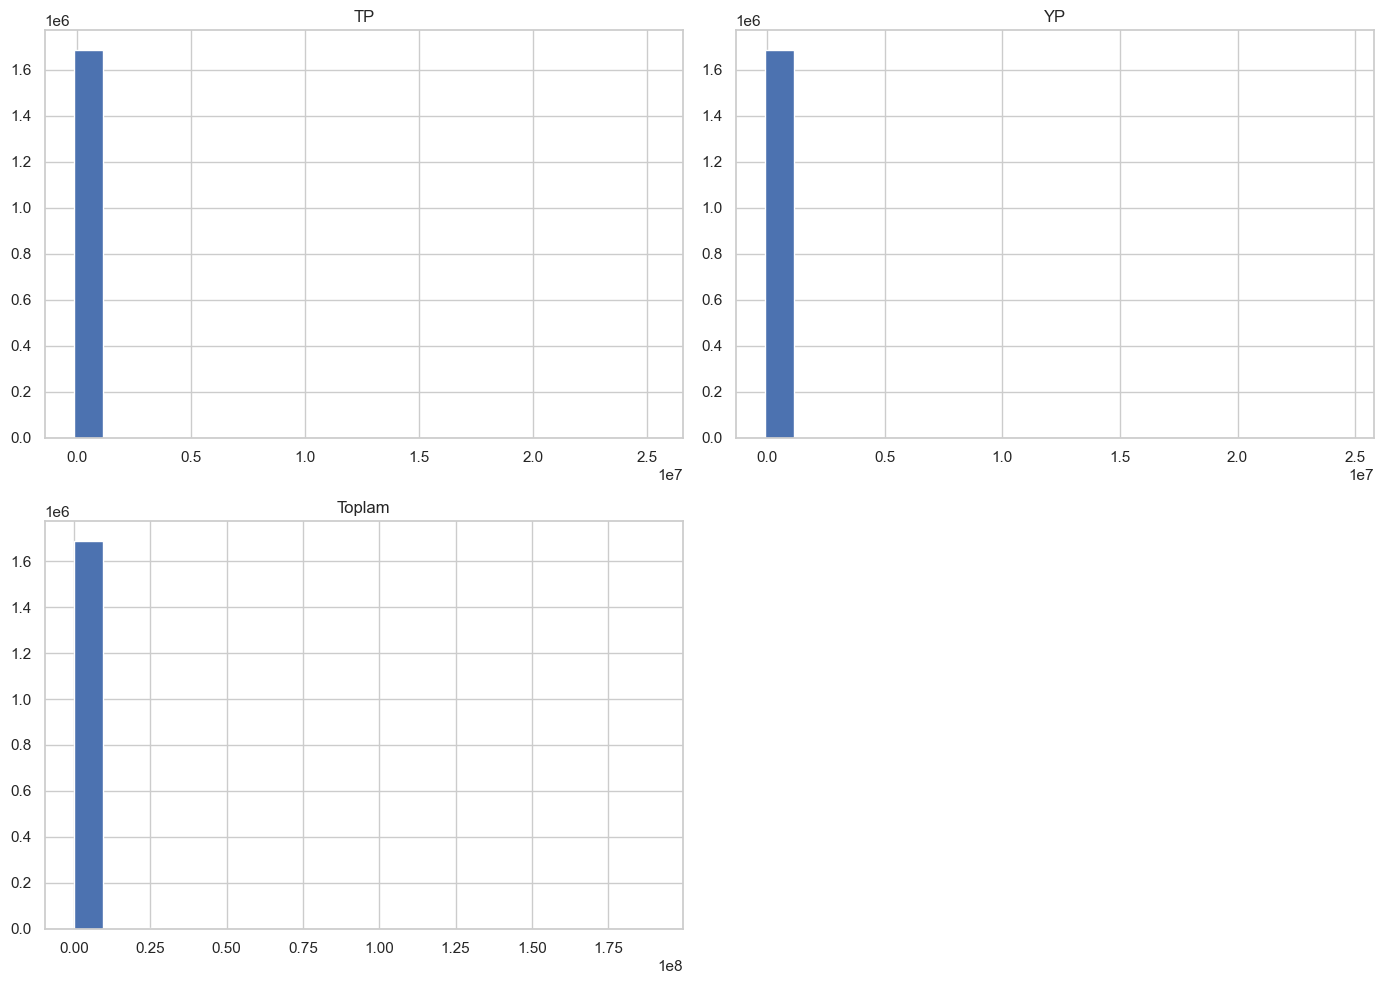

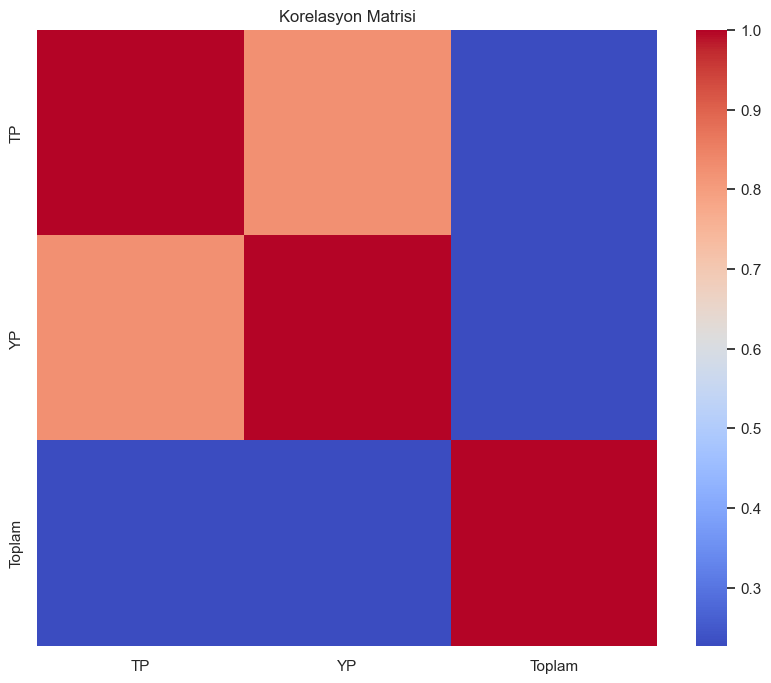

Hedef sütunu veride bulunamadı; dağılım grafiği atlandı.


In [6]:
# Keşifsel görselleştirmeler

# Sayısal sütunların histogramları
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()
plt.figure(figsize=(12, 8))
df_clean[num_cols].hist(bins=20, figsize=(14, 10))
plt.tight_layout()

# Korelasyon ısı haritası (sayısal)
plt.figure(figsize=(10, 8))
cor = df_clean[num_cols].corr()
sns.heatmap(cor, annot=False, cmap='coolwarm')
plt.title('Korelasyon Matrisi')
plt.show()

# Hedef dağılımı
if TARGET is not None and TARGET in df_clean.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x=TARGET, data=df_clean)
    plt.title('Hedef Dağılımı')
    plt.show()
else:
    print('Hedef sütunu veride bulunamadı; dağılım grafiği atlandı.')


In [7]:
# Özellik mühendisliği ve encoding
# Kategorikleri one-hot yap (çok yüksek kardinalite yoksa); alternatif olarak LabelEncoder kullanılabilir
cat_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()
print('Kategorik sütun sayısı:', len(cat_cols))

# Küçük demo: eğer çok kardinal değilse one-hot
max_unique = 50
ohe_cols = [c for c in cat_cols if df_clean[c].nunique() <= max_unique]
print('One-hot yapılacak sütunlar (<=50 benzersiz):', ohe_cols[:10])

df_model = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

# Hedef ve özelliklerin ayrılması
if TARGET is not None and TARGET in df_model.columns:
    y = df_model[TARGET]
    X = df_model.drop(columns=[TARGET])
else:
    # hedef yoksa demo amaçlı son sütunu hedef say
    y = None
    X = df_model

print('Model için X şekli:', X.shape)
if y is not None:
    print('y dağılımı:\n', y.value_counts())


Kategorik sütun sayısı: 5
One-hot yapılacak sütunlar (<=50 benzersiz): ['Taraf', 'Tablo', 'Birim']
Model için X şekli: (1693200, 38)


In [8]:
# Basit modelleme: Logistic Regression ve Random Forest (cross-val ile hızlı değerlendirme)
if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000))])
    pipe_rf = Pipeline([('scaler', StandardScaler()), ('rf', RandomForestClassifier(n_estimators=100, random_state=42))])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print('Logistic Regression CV accuracy:', cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='accuracy').mean())
    print('Random Forest CV accuracy:', cross_val_score(pipe_rf, X_train, y_train, cv=cv, scoring='accuracy').mean())

    # Model eğit ve test et (örnek olarak RandomForest)
    pipe_rf.fit(X_train, y_train)
    y_pred = pipe_rf.predict(X_test)
    print('\nTest set sonuçları:')
    print(classification_report(y_test, y_pred))

    # ROC-AUC (eğer olasılık verilebiliyorsa)
    if hasattr(pipe_rf, 'predict_proba'):
        y_proba = pipe_rf.predict_proba(X_test)[:,1]
        try:
            print('ROC-AUC:', roc_auc_score(y_test, y_proba))
        except Exception as e:
            print('ROC hesaplanamadı:', e)
else:
    print('Hedef değişken bulunamadığı için modelleme atlandı.')


Hedef değişken bulunamadığı için modelleme atlandı.


In [9]:
# Modeli ve temizlenmiş veriyi kaydet
clean_fn = 'banking_cleaned.csv'
df_clean.to_csv(clean_fn, index=False)
print('Temizlenmiş veri kaydedildi:', clean_fn)

# Model kaydı (eğer eğitim yapıldıysa)
try:
    joblib.dump(pipe_rf, 'banking_rf_pipeline.joblib')
    print('Model kaydedildi: banking_rf_pipeline.joblib')
except Exception as e:
    print('Model kaydedilemedi:', e)


Temizlenmiş veri kaydedildi: banking_cleaned.csv
Model kaydedilemedi: name 'pipe_rf' is not defined


# Kısa sonuç: Sonraki adımlar ve notlar

- Veri hızlıca temizlendi ve temel imputasyon uygulandı.
- Hedef sütunu otomatik seçme deneniyor; eğer yanlış sütun seçilmişse lütfen belirtin, hedef sütununu manuel atarım.
- Baseline modeller (Logistic Regression, RandomForest) ile hızlı değerlendirme yapıldı; ileri çalışma için:
  - Daha kapsamlı özellik mühendisliği
  - Dengesizlik varsa SMOTE/weighting
  - Hiperparametre optimizasyonu (Optuna/RandomizedSearchCV)
  - Açıklama için SHAP eklenebilir

Teşekkürler — dilediğiniz eklemeler veya değişiklikler varsa söyleyin.
